In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

pathImg = r"C:\Users\COMPUTER WORLD\Desktop/23u03121_23u03086/DIPproject/L2/zebra.png"
img = cv.imread(pathImg, cv.IMREAD_GRAYSCALE)
h, w = img.shape
type(img), img.shape

(numpy.ndarray, (181, 200))

### Edge Detection Function

In [7]:
def edgeMask(img: np.ndarray, kernelSize: int = 2, threshold: int = 10000, PredefinedKernel_name: str = None ) -> np.ndarray:

    matrices = {
    "Roberts": (
        np.array([
            [0, 1],
            [-1, 0]
        ]),
        np.array([
            [1, 0],
            [0, -1]
        ])
    ),

    "Prewitt": (
        np.array([
            [-1, 0, 1],
            [-1, 0, 1],
            [-1, 0, 1]
        ]),
        np.array([
            [1, 1, 1],
            [0, 0, 0],
            [-1, -1, -1]
        ])
    ),

    "Sobel3x3": (
        np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ]),
        np.array([
            [1, 2, 1],
            [0, 0, 0],
            [-1, -2, -1]
        ])
    ),

    "Sobel5x5": (
        np.array([
            [-1, -2,  0,  2,  1],
            [-2, -3,  0,  3,  2],
            [-3, -5,  0,  5,  3],
            [-2, -3,  0,  3,  2],
            [-1, -2,  0,  2,  1]
        ]),
        np.array([
            [ 1,  2,  3,  2,  1],
            [ 2,  3,  5,  3,  2],
            [ 0,  0,  0,  0,  0],
            [-2, -3, -5, -3, -2],
            [-1, -2, -3, -2, -1]
        ])
    )
}
        
    r, c = img.shape
    k = kernelSize

    if PredefinedKernel_name:
        del_by_del_x, del_by_del_y  = matrices[PredefinedKernel_name]
        k = del_by_del_x.shape[0]
    else:
        del_by_del_x[0, : ] = -1*(k-1)
        del_by_del_y[ : , 0] = -1*(k-1)

    
    magnitude: float = 0.0
    mask = np.zeros((r, c), dtype=int)
    img1 = cv.copyMakeBorder(img, 0, k-1, 0, k-1, borderType=cv.BORDER_REPLICATE)

    
    for i in range(r):
        for j in range(c):
            window = img1[i : i+k, j : j+k]
            magnitude = (np.sum(del_by_del_x*window))**2 + (np.sum(del_by_del_y*window))**2
            if(magnitude>=threshold): mask[i][j] = 255
    
    return mask
            
    
    

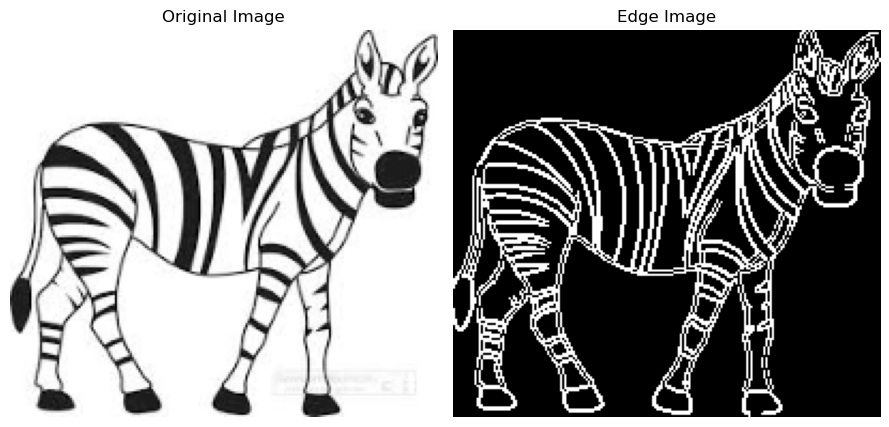

In [16]:
edge = edgeMask(img,threshold=200000, PredefinedKernel_name="Sobel3x3")

# --- Display both images side by side ---
plt.figure(figsize=(9, 5))  # width, height in inches

# Left: Original Image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Right: Cropped Document
plt.subplot(1, 2, 2)
plt.imshow(edge, cmap='gray')
plt.title("Edge Image")
plt.axis("off")

# --- Show the figure ---
plt.tight_layout()
plt.show()